# 02. 피처 설계와 베이스라인

01번에서 확인한 것 중 **이 노트북의 설계를 바꾼 세 가지**:

1. **품목마다 성격이 완전히 다르다.** 생강은 58.2%, 양파는 22.6% 의 날이 전일과
   값이 같다(원천 미갱신). 전 품목 평균 성능은 이 둘 때문에 좋아 보이는 착시가
   생기므로 **품목별로 따로 평가한다.**
2. **가장 강한 신호는 계절이다.** 배추는 9월이 6월의 2.6배. 명절 효과(+0.8%)와는
   비교가 안 된다. 명절은 미나리(+25%)·파(+8.4%)에만 있다.
3. **외생변수는 약하다.** 기온 |rho| 0.26~0.28, 출하량 0.10~0.11. 시차를 줘서
   살아나는지 여기서 확인한다.

## 이 노트북의 설계 결정

**예측 문제** — `h=7 거래일` 뒤 가격을 예측한다. 1일 앞은 naive(어제 값 그대로)가
MAPE 0.53~4.80% 로 너무 강해 개선 여지가 거의 없다. 도매가 데이터는 평일만
있으므로 7 거래일은 달력으로 약 9~10일, 실무의 "1~2주 뒤"에 해당한다.

**타깃은 가격이 아니라 로그 수익률** `y = log(p[t+h] / p[t])` 이다. 이유:
- 가격 수준이 품목별로 6배 차이(배추 1,205원 vs 미나리 7,428원)라 한 모델로
  수준을 맞추면 비싼 품목의 오차가 손실을 지배한다.
- 로그 수익률로 두면 **naive 베이스라인이 정확히 `y_hat = 0`** 이 되어,
  "모델이 naive 를 이겼는가"가 그대로 읽힌다.

**룩어헤드 차단** — 아래 1절에 규칙을 적었다. 이게 이 노트북에서 가장 틀리기
쉬운 부분이다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 4)
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
CACHE = ROOT / "notebooks" / ".cache" / "mart.parquet"

# 01번이 만든 캐시를 그대로 쓴다. 없으면 01번을 먼저 돌린다.
df = pd.read_parquet(CACHE)
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())
print(f"{len(df):,}행 | {df.price_date.min():%Y-%m-%d} ~ {df.price_date.max():%Y-%m-%d}")

8,220행 | 2021-01-04 ~ 2026-08-06


## 1. 룩어헤드 차단 규칙

시계열에서 성능이 비현실적으로 좋게 나오면 거의 항상 미래를 봤기 때문이다.
여기서는 세 가지를 지킨다.

**규칙 1 — 가격 피처는 전부 `t` 시점까지만.** rolling 은 `center=False`(기본)로
두고, 01번 5절에서 쓴 `center=True` 이동중앙값은 **여기 절대 가져오지 않는다.**
그건 EDA 전용이었다.

**규칙 2 — 외생변수(기상·출하량)는 한 칸 더 미룬다(`shift(1)`).**
같은 날 값을 그대로 쓰면 예측 시점에 알 수 없는 정보가 된다. 특히 ASOS 는
**전날 자료까지만 제공**하고, datago 출하량도 당일치가 그날 바로 확정되지
않는다(01번에서 최신일 행 수가 절반이었던 이유).

**규칙 3 — 달력 피처는 미루지 않는다.** 명절·절기·요일은 미래도 이미 확정이라
예측 시점에 알 수 있다. 오히려 이게 달력 피처의 존재 이유다.

In [2]:
H = 7   # 예측 지평(거래일)

# 외생변수 — 규칙 2 에 따라 shift(1) 한다
EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
       "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
# 달력 — 미래도 확정이므로 그대로 쓴다 (규칙 3)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src: pd.DataFrame, h: int = H) -> pd.DataFrame:
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def g(col):
        return d.groupby("item")[col]   # 매번 새로 묶어 stale grouper 를 피한다

    # 타깃: h 거래일 뒤 로그 수익률. shift(-h) 로 미래를 보지만 이건 정답이다.
    d["y"] = g("_logp").shift(-h) - d._logp

    # 과거 수익률 (t 시점까지만)
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)

    # 이동평균 대비 위치 + 변동성
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())

    # 외생변수 — 한 칸 미루고, 20일 평균 대비 편차도 같이 준다
    for c in EXO:
        d[f"{c}_l1"] = g(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - g(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())

    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


feat = build(df)
FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
         + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
         + [f"{c}_l1" for c in EXO] + [f"{c}_d20" for c in EXO]
         + CAL + ["item_code"])
print(f"피처 {len(FEATS)}개 | 타깃 결측 {feat.y.isna().mean():.1%} (각 품목 마지막 {H}일은 정답이 없다)")

피처 36개 | 타깃 결측 0.5% (각 품목 마지막 7일은 정답이 없다)


## 2. 시간 순서 분할

**랜덤 분할은 쓰면 안 된다.** 미래 행이 학습에 섞이면 성능이 부풀고, 실제
운영(오늘까지 배워서 다음 주를 맞힘)과 조건이 달라진다.

- train : ~ 2024-12-31 (4년)
- valid : 2025 (1년)
- test : 2026 ~ (약 7개월) — 마지막에 한 번만 본다

경계에서 타깃이 넘겨다보는 문제도 막아야 한다. `y` 는 `t+7` 을 보므로 train
마지막 며칠의 정답은 valid 구간에 걸쳐 있다. 그 행들은 **버린다**(embargo).

In [3]:
TR_END, VA_END = pd.Timestamp("2024-12-31"), pd.Timestamp("2025-12-31")
EMBARGO = pd.Timedelta(days=int(H * 1.5))   # 거래일 h 개 ≈ 달력 1.5h 일

d = feat.dropna(subset=["y"]).copy()
tr = d[d.price_date <= TR_END - EMBARGO]
va = d[(d.price_date > TR_END) & (d.price_date <= VA_END - EMBARGO)]
te = d[d.price_date > VA_END]

for name, part in (("train", tr), ("valid", va), ("test", te)):
    print(f"{name:6} {len(part):>5,}행  {part.price_date.min():%Y-%m-%d} ~ {part.price_date.max():%Y-%m-%d}")

train  5,856행  2021-01-04 ~ 2024-12-20
valid  1,410행  2025-01-02 ~ 2025-12-19
test     834행  2026-01-02 ~ 2026-07-28


## 3. 베이스라인

타깃이 로그 수익률이라 **naive 는 `y_hat = 0`**(가격이 안 변한다는 예측)이다.
비교 대상으로 둘을 더 둔다.

- **drift** : 최근 20일 평균 수익률이 그대로 이어진다고 본다
- **seasonal** : 작년 같은 시기의 같은 구간 수익률 (계절이 가장 강한 신호였으므로)

평가는 로그 수익률이 아니라 **원 가격으로 되돌려 MAPE** 로 한다. 로그 공간의
RMSE 는 품목 간 비교가 직관적이지 않고, 01번에서 잰 naive MAPE 와도 같은
척도여야 이어서 읽을 수 있다.

In [4]:
def mape_by_item(part: pd.DataFrame, y_pred) -> pd.Series:
    """로그 수익률 예측을 가격으로 되돌려 품목별 MAPE(%) 를 낸다."""
    y_pred = np.asarray(y_pred, dtype=float)
    actual = part.price_kg_avg.values * np.exp(part.y.values)
    pred = part.price_kg_avg.values * np.exp(y_pred)
    err = pd.Series(np.abs(pred - actual) / actual, index=part.index)
    return (err.groupby(part.item).mean() * 100).round(2)


scores = {}
scores["naive"] = mape_by_item(te, np.zeros(len(te)))
scores["drift"] = mape_by_item(te, (te.ret20 / 20 * H).fillna(0.0).values)

# seasonal: 약 1년 전(364일 = 52주) 같은 요일의 h일 수익률
prev = d.set_index(["item", "price_date"]).y
key = pd.MultiIndex.from_arrays([te.item, te.price_date - pd.Timedelta(days=364)])
scores["seasonal"] = mape_by_item(te, prev.reindex(key).fillna(0.0).values)

base = pd.DataFrame(scores)
display(base)
print("\n※ naive 열이 앞으로 넘어야 할 선이다.")

,naive,drift,seasonal
item,,,
감자,7.79,9.11,13.02
미나리,11.95,13.31,12.19
배추,7.65,8.37,13.81
생강,0.37,0.63,1.43
양파,8.29,9.69,9.82
파,10.18,12.29,12.07



※ naive 열이 앞으로 넘어야 할 선이다.


## 4. 모델

`HistGradientBoostingRegressor` 를 쓴다. 표본이 품목당 1,300여 일이고 피처가
40개 남짓이라 부스팅이 무난하다. 딥러닝을 쓸 규모가 아니다.

**품목별 모델이 아니라 전 품목 하나로 학습**하고 `item_code` 를 범주 피처로 준다.
품목별로 나누면 학습 표본이 1,300행으로 줄어드는데, 계절·명절처럼 품목 간에
공유되는 구조가 있어 같이 배우는 편이 유리하다. 대신 **평가는 품목별로** 한다
(01번에서 확인한 대로 품목 성격이 다르므로).

손실은 `absolute_error` — MAPE 로 평가하니 제곱오차보다 정합적이고, 농산물
가격 특유의 급등 이상치에 덜 끌린다.

In [5]:
CAT_IDX = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

model = HistGradientBoostingRegressor(
    loss="absolute_error",
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=15,        # 표본이 적어 트리를 얕게
    min_samples_leaf=40,
    l2_regularization=1.0,
    categorical_features=CAT_IDX,
    early_stopping=False,     # valid 로 직접 반복수를 고른다(아래)
    random_state=42,
)
model.fit(tr[FEATS], tr.y)

va_mape = mape_by_item(va, model.predict(va[FEATS]))
print("valid MAPE(%):")
print(va_mape.to_string())

scores["model"] = mape_by_item(te, model.predict(te[FEATS]))
result = pd.DataFrame(scores)
result["naive대비%"] = ((result["model"] / result["naive"] - 1) * 100).round(1)
display(result)

valid MAPE(%):
item
감자      8.65
미나리     8.44
배추     13.78
생강      3.43
양파      5.69
파       9.41


,naive,drift,seasonal,model,naive대비%
item,,,,,
감자,7.79,9.11,13.02,7.32,-6.0
미나리,11.95,13.31,12.19,9.07,-24.1
배추,7.65,8.37,13.81,7.45,-2.6
생강,0.37,0.63,1.43,0.57,54.1
양파,8.29,9.69,9.82,7.90,-4.7
파,10.18,12.29,12.07,9.95,-2.3


## 5. 결과 읽기

`naive대비%` 가 **음수면 개선**, 양수면 naive 보다 못한 것이다.

주의해서 읽어야 할 것: **생강·양파의 낮은 MAPE 는 실력이 아니다.** 01번에서
확인했듯 생강은 58.2%, 양파는 22.6% 의 날이 전일과 값이 같아 애초에 변화가
없다. 이 둘을 포함해 전체 평균을 내면 성능이 좋아 보이는 착시가 생긴다.

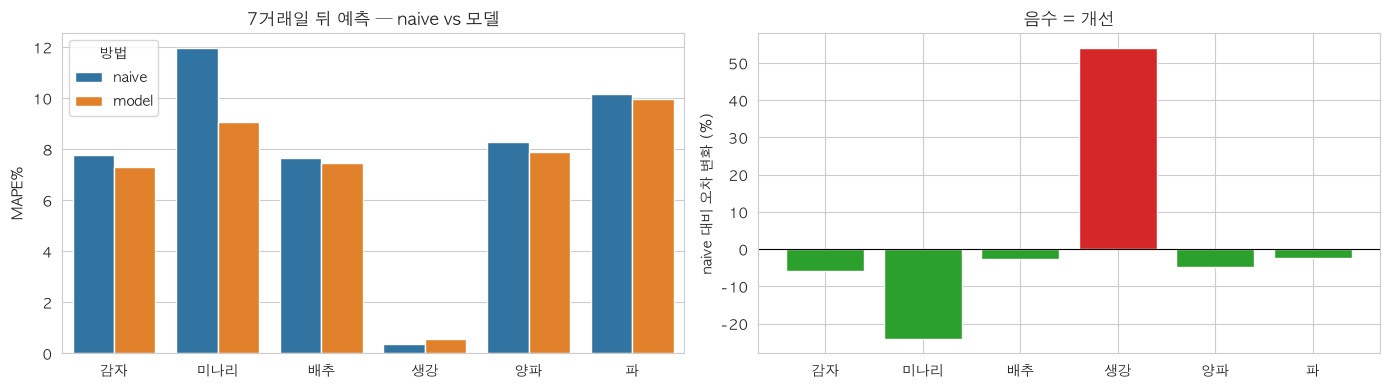

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_df = result[["naive", "model"]].reset_index().melt(
    id_vars="item", var_name="방법", value_name="MAPE%")
sns.barplot(data=plot_df, x="item", y="MAPE%", hue="방법", ax=axes[0])
axes[0].set_title(f"{H}거래일 뒤 예측 — naive vs 모델")
axes[0].set_xlabel("")

colors = ["tab:green" if v < 0 else "tab:red" for v in result["naive대비%"]]
axes[1].bar(result.index, result["naive대비%"], color=colors)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("naive 대비 오차 변화 (%)")
axes[1].set_title("음수 = 개선")
plt.tight_layout()
plt.show()

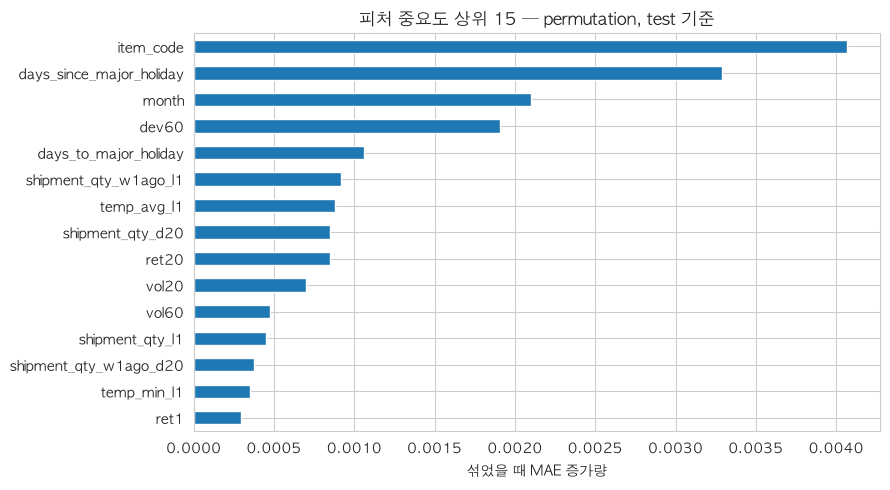

item_code                   0.00407
days_since_major_holiday    0.00329
month                       0.00210
dev60                       0.00191
days_to_major_holiday       0.00106
shipment_qty_w1ago_l1       0.00092
temp_avg_l1                 0.00088
shipment_qty_d20            0.00085
ret20                       0.00085
vol20                       0.00070


In [7]:
# 어떤 피처가 실제로 쓰였는지. test 에서 재면 일반화된 기여를 본다.
imp = permutation_importance(model, te[FEATS], te.y, n_repeats=5,
                             random_state=42, scoring="neg_mean_absolute_error")
top = (pd.Series(imp.importances_mean, index=FEATS)
       .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
top[::-1].plot.barh(ax=ax)
ax.set_xlabel("섞었을 때 MAE 증가량")
ax.set_title("피처 중요도 상위 15 — permutation, test 기준")
plt.tight_layout()
plt.show()
print(top.head(10).round(5).to_string())

## 6. 정리

### 결과 — 7거래일 뒤 예측, test 2026-01~07 (834행)

| 품목 | naive | drift | seasonal | **모델** | naive 대비 |
|---|---|---|---|---|---|
| 미나리 | 11.95 | 13.31 | 12.19 | **9.07** | **-24.1%** |
| 감자 | 7.79 | 9.11 | 13.02 | **7.32** | **-6.0%** |
| 양파 | 8.29 | 9.69 | 9.82 | **7.90** | **-4.7%** |
| 배추 | 7.65 | 8.37 | 13.81 | **7.45** | **-2.6%** |
| 파 | 10.18 | 12.29 | 12.07 | **9.95** | **-2.3%** |
| 생강 | 0.37 | 0.63 | 1.43 | 0.57 | **+54.1%** |

(단위 MAPE %, 음수가 개선)

### 읽어야 할 것

**1. 6품목 중 5품목에서 naive 를 이겼다.** 다만 개선폭은 미나리(-24.1%)를 빼면
2~6% 로 크지 않다. 농산물 도매가가 그만큼 랜덤워크에 가깝다는 뜻이고,
**naive 를 이기는 것 자체가 낮은 기준이 아니다.**

**2. 생강은 모델을 쓰면 안 된다(+54.1% 악화).** 01번에서 본 대로 58.2% 의 날이
전일과 값이 같아 naive MAPE 가 0.37% 다. 여기에 모델이 무언가를 예측하면
없는 변동을 만들어내 오히려 나빠진다. **정체 품목은 naive 로 두는 것이 맞다.**
양파(22.6% 정체)는 -4.7% 로 아직 이득이 있어 경계선이다.

**3. 미나리의 -24.1% 는 명절 때문으로 보인다.** 01번에서 미나리만 D-7~D-1 에
+25.0% 였고, 피처 중요도에서도 `days_since_major_holiday`(2위)·
`days_to_major_holiday`(5위)가 상위다. **달력 피처가 값을 하는 품목이 따로 있다.**

**4. 피처 중요도 상위가 달력·계절이다.** `item_code` → `days_since_major_holiday`
→ `month` → `dev60` → `days_to_major_holiday` 순. 01번 EDA 에서 "가장 강한
신호는 계절"이라고 본 것과 일치한다.

**5. 외생변수는 시차를 주니 살아났다.** 01번 동시점 상관에서 출하량은 0.10~0.11,
기온은 0.26~0.28 로 약했는데, `shipment_qty_w1ago_l1`(6위)·`temp_avg_l1`(7위)·
`shipment_qty_d20`(8위)가 상위 10 에 들어왔다. **동시점 상관이 약하다고 버릴
변수가 아니었다.**

**6. drift 와 seasonal 은 naive 보다 나쁘다.** 특히 seasonal(작년 같은 시기
수익률)은 감자에서 13.02 vs naive 7.79 로 크게 뒤진다. 계절성은 **수준**에는
강하게 남지만 **단기 수익률**을 그대로 재현하지는 않는다.

**7. 지평이 길어지면 크게 어려워진다.** 01번의 1일 앞 naive MAPE 는 0.53~4.80%
였는데 7거래일 앞은 0.37~11.95% 다. 감자는 1.75% → 7.79% 로 4배 넘게 늘었다.

### 한계 — 이 결과를 과신하면 안 되는 이유

- **test 가 7개월(834행)뿐이다.** 2026년 한 구간의 결과이고, valid(2025)에서는
  배추가 13.78% 로 test(7.45%)의 두 배였다. **연도 변동이 개선폭보다 크다.**
- 하이퍼파라미터를 **튜닝하지 않았다**(valid 를 눈으로만 봤다).
- 기상은 2026-07-29 이후 결측이다(ASOS 활용신청 만료). test 끝부분에 영향.

### 다음에 할 것

1. **품목별 전략 분기** — 생강은 naive 고정, 나머지는 모델. 정체율을 기준으로
   자동 분기하는 규칙을 두는 편이 안전하다.
2. **롤링 원점 검증(walk-forward)** — 단일 분할로는 연도 변동을 못 걸러낸다.
3. **명절 상호작용** — `days_to_major_holiday × item` 을 명시적으로 주면
   미나리·파에 더 맞을 수 있다.
4. **수입량(관세청) 검토** — 양파 개선폭이 -4.7% 로 작다. 수입 물량이 설명하지
   못하는 구간인지 잔차로 먼저 확인하고 붙일지 정한다.
